In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('alphatrade_phase1.csv')

df = df.dropna()

df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,Daily_Return,Volatility,RSI,MACD,Signal_Line,BB_Middle,BB_Upper,BB_Lower,Signal
49,2020-03-13,67.102936,67.573676,61.063019,63.945381,370732000,70.642751,73.733388,69.706664,72.175713,0.119808,0.055299,45.068586,-2.642671,-2.022674,70.642751,80.593466,60.692037,-1
50,2020-03-16,58.470341,62.542813,57.936837,58.407573,322423600,69.644065,73.456118,68.636538,71.638247,-0.128647,0.061639,40.052941,-3.202934,-2.258726,69.644065,80.283504,59.004625,-1
51,2020-03-17,61.041286,62.187949,57.550590,59.749776,324056000,68.845743,73.244331,67.913180,71.222680,0.043970,0.062905,41.593066,-3.400295,-2.487040,68.845743,79.554588,58.136898,-1
52,2020-03-18,59.547005,60.350879,57.241600,57.881322,300233600,67.916942,72.991243,67.116402,70.764811,-0.024480,0.062721,43.998933,-3.635376,-2.716707,67.916942,78.458812,57.375073,-1
53,2020-03-19,59.090748,61.036459,58.566903,59.720811,271857200,67.005404,72.735821,66.352054,70.307004,-0.007662,0.062726,43.661296,-3.814523,-2.936270,67.005404,77.272466,56.738341,-1


In [13]:
df['Target'] = (
    df['Close'].shift(-1)
    > df['Close']
).astype(int)

df = df[:-1]

In [14]:
features = [
    'Close',
    'Volume',
    'SMA_20',
    'SMA_50',
    'EMA_20',
    'EMA_50',
    'Daily_Return',
    'Volatility',
    'RSI',
    'MACD',
    'Signal_Line'
]

X = df[features]
y = df['Target']

In [15]:
# Train the final model
from sklearn.ensemble import RandomForestClassifier

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [16]:
# Build the backtest dataframe
backtest = pd.DataFrame()

backtest['Actual'] = y_test.values
backtest['Prediction'] = predictions
backtest['Close'] = (
    df['Close']
    .iloc[split:]
    .values
)

backtest.head()

,Actual,Prediction,Close
0,0,1,228.387939
1,0,1,224.229111
2,0,1,221.251450
3,1,1,220.358139
4,0,0,221.787399


Trading strategy

Our strategy:

Prediction = 1
Buy

Prediction = 0
Stay out

In [17]:
backtest['Market_Return'] = (
    backtest['Close']
    .pct_change()
)

backtest['Strategy_Return'] = (
    backtest['Prediction']
    * backtest['Market_Return']
)

In [18]:
backtest['Cumulative_Market'] = (
    1 + backtest['Market_Return']
).cumprod()

backtest['Cumulative_Strategy'] = (
    1 + backtest['Strategy_Return']
).cumprod()

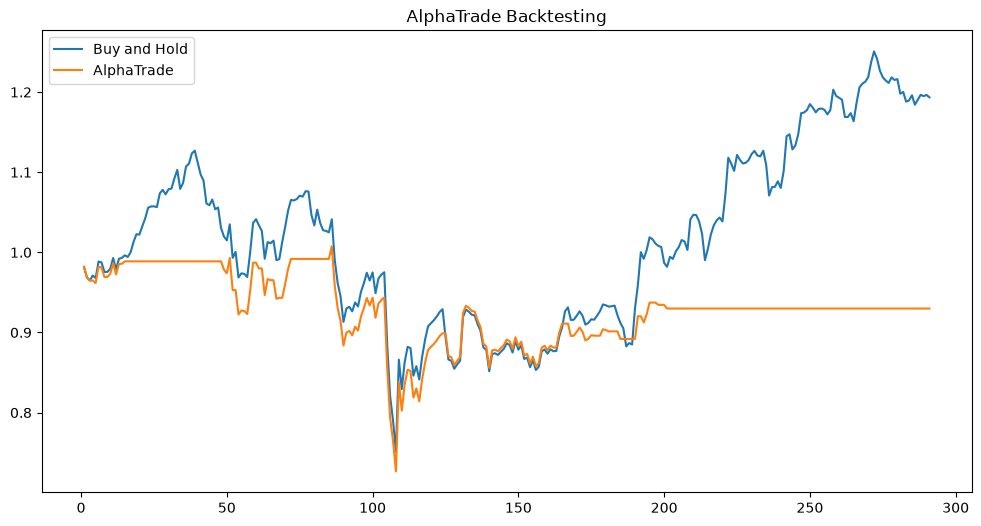

In [19]:
# Plot Result
plt.figure(figsize=(12,6))

plt.plot(
    backtest['Cumulative_Market'],
    label='Buy and Hold'
)

plt.plot(
    backtest['Cumulative_Strategy'],
    label='AlphaTrade'
)

plt.legend()

plt.title(
    'AlphaTrade Backtesting'
)

plt.show()

In [20]:
# Final Profit
market_profit = (
    backtest['Cumulative_Market']
    .iloc[-1]
)

strategy_profit = (
    backtest['Cumulative_Strategy']
    .iloc[-1]
)

print(
    "Market Return:",
    market_profit
)

print(
    "AlphaTrade Return:",
    strategy_profit
)

Market Return: 1.1934673433980743
AlphaTrade Return: 0.9298939041924852
